# 🚚 Freight Cost Prediction Analysis & Modeling

## Overview
This notebook analyzes historical vendor invoice records to understand the factors driving freight and shipping expenses. Using statistical analysis, correlation studies, and regression modeling, we build and evaluate machine learning models that predict shipping/freight costs for incoming vendor invoices based on invoice dollar amounts.

---

## 🗄️ Database & Tables Referenced
- **Database File**: `inventory.db` (SQLite)
- **Tables Referenced**:
  1. **`sqlite_master`**: Queried to retrieve metadata on all existing tables in the database.
  2. **`vendor_invoice`**: Header-level invoice records from vendors.
- **Columns Extracted & Analyzed**:
  - `Quantity`: Total physical units/quantity shipped in the invoice.
  - `Dollars`: Total monetary value (in USD) of the invoice.
  - `Freight`: Actual freight/shipping cost charged on the invoice (**Target Variable**).
  - `Freight_per_Unit` *(Engineered)*: `Freight / Quantity` to assess volume efficiency.

---

## 🔄 Workflow Steps
1. **Database Connection & Schema Exploration**: Inspect all tables in `inventory.db`.
2. **Data Extraction & Correlation Analysis**: Extract `vendor_invoice` and compute correlation matrices and scatter plots.
3. **Feature Engineering & Quantile Analysis**: Create `Freight_per_Unit` and analyze shipping cost differences between low-volume (Q1) and high-volume (Q3) orders.
4. **Data Splitting**: Split data into training (80%) and testing (20%) sets.
5. **Model Training & Benchmarking**: Train and compare **Linear Regression**, **Decision Tree Regressor**, and **Random Forest Regressor**.
6. **Model Evaluation**: Measure performance using **MAE**, **RMSE**, and **R² Score**.
7. **Inference**: Test model predictions against new sample invoice dollar amounts.



### Step 1: Import Dependencies
Imports essential Python libraries for data manipulation (`pandas`, `numpy`), database queries (`sqlite3`), data visualization (`matplotlib`, `seaborn`), and machine learning preprocessing (`sklearn.model_selection.train_test_split`).


In [99]:
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Step 2: Connect to SQLite Database & Query Table Names
- **Database**: `inventory.db`
- **Table Referenced**: `sqlite_master`
- **Columns Extracted**: `name` (table names)
- **Description**: Connects to the SQLite inventory database and retrieves all existing table names.


In [100]:
conn = sqlite3.connect(r'D:\PROJECTS\INVOICE\data\inventory.db')

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

print(tables)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


### Step 3: Display Table Names
Displays the list of tables available in the SQLite database (`purchases`, `purchase_prices`, `vendor_invoice`, `begin_inventory`, `end_inventory`).


In [101]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


### Step 4: Preview Schema & Sample Data for All Tables
- **Tables Queried**: `purchases`, `purchase_prices`, `vendor_invoice`, `begin_inventory`, `end_inventory`
- **Description**: Iterates through each table in the database and displays the top 5 records to inspect table structure and schema.


In [102]:
for table in tables['name']:
    print(f"Table: {table}")
    df = pd.read_sql_query(f'SELECT * FROM {table} limit 5', conn)
    display(df)
    
 

Table: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


### Step 5: Load Vendor Invoice Data
- **Table Referenced**: `vendor_invoice`
- **Columns Extracted**: `VendorNumber`, `VendorName`, `InvoiceDate`, `PONumber`, `PODate`, `PayDate`, `Quantity`, `Dollars`, `Freight`, `Approval`
- **Description**: Loads the complete `vendor_invoice` table into a pandas DataFrame (`vendor_df`) for exploratory analysis and modeling.


In [103]:
vendor_df=pd.read_sql_query('SELECT * FROM vendor_invoice', conn)
display(vendor_df)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN
...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,NaN
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,NaN
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,NaN
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,NaN


### Step 6: Compute Correlation Matrix
- **Columns Analyzed**: `Quantity`, `Freight`, `Dollars`
- **Description**: Computes the Pearson correlation matrix to quantify relationships between shipment volume, invoice dollar amounts, and freight cost.


In [104]:
vendor_df[['Quantity', 'Freight', 'Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


### Step 7: Visualize Correlations & Scatter Relationships
- **Columns Visualized**: `Quantity`, `Dollars`, `Freight`
- **Description**: Generates a correlation heatmap and scatter plots comparing `Quantity vs Freight` and `Dollars vs Freight` to examine linear trends.


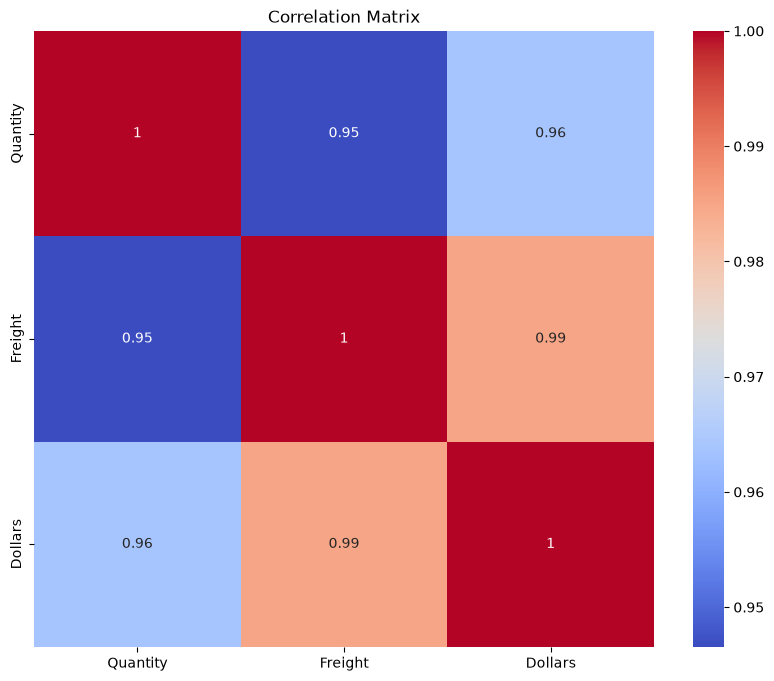

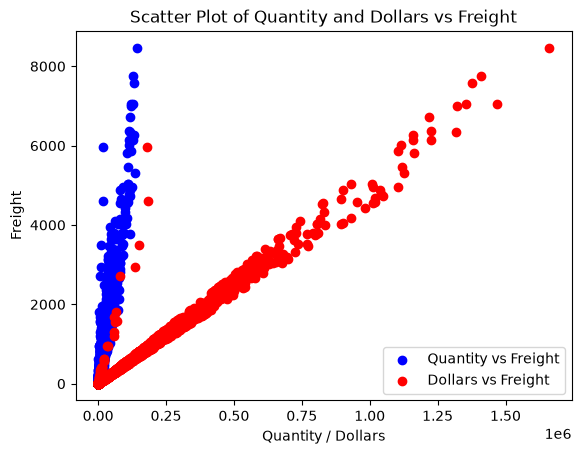

In [105]:
plt.figure(figsize=(10, 8))
sns.heatmap(vendor_df[['Quantity', 'Freight', 'Dollars']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

plt.scatter(vendor_df['Quantity'], vendor_df['Freight'],color='blue')
plt.scatter(vendor_df['Dollars'], vendor_df['Freight'],color='red')
plt.legend(['Quantity vs Freight', 'Dollars vs Freight'])
plt.title('Scatter Plot of Quantity and Dollars vs Freight')
plt.xlabel('Quantity / Dollars')
plt.ylabel('Freight')
plt.show()

### Step 8: Feature Engineering - Freight per Unit
- **Source Columns**: `Freight`, `Quantity` (from `vendor_invoice`)
- **Engineered Feature**: `Freight_per_Unit` = `Freight / Quantity`
- **Description**: Calculates the freight expense incurred per individual unit shipped.


In [106]:
vendor_df['Freight_per_Unit'] = vendor_df['Freight'] / vendor_df['Quantity']
display(vendor_df)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,Freight_per_Unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN,0.221809
...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,NaN,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,NaN,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,NaN,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,NaN,0.033117


### Step 9: Compute Quantity Quartile Thresholds (Q1 & Q3)
- **Column Analyzed**: `Quantity`
- **Description**: Calculates the 25th percentile (`low_qunt`) and 75th percentile (`high_qunt`) thresholds to separate low-volume from high-volume shipments.


In [107]:
low_qunt=vendor_df['Quantity'].quantile(0.25)
high_qunt=vendor_df['Quantity'].quantile(0.75)
print(f"Low Quantity Threshold: {low_qunt}")
print(f"High Quantity Threshold: {high_qunt}")

Low Quantity Threshold: 83.0
High Quantity Threshold: 5100.5


### Step 10: Average Freight per Unit for Low-Volume Shipments (< Q1)
- **Columns Used**: `Quantity`, `Freight_per_Unit`
- **Description**: Computes the mean unit freight cost for orders in the bottom 25% of quantity to evaluate smaller shipment overhead.


In [108]:
vendor_df.loc[vendor_df['Quantity'] < low_qunt, 'Freight_per_Unit'].mean()
                        


np.float64(0.09489854253138316)

### Step 11: Average Freight per Unit for High-Volume Shipments (> Q3)
- **Columns Used**: `Quantity`, `Freight_per_Unit`
- **Description**: Computes the mean unit freight cost for orders in the top 25% of quantity, illustrating volume discounts / economies of scale.


In [109]:
vendor_df.loc[vendor_df['Quantity'] > high_qunt, 'Freight_per_Unit'].mean()

np.float64(0.049077654690759046)

### Step 12: Define Feature Matrix (X) and Target Vector (y)
- **Feature (X)**: `Dollars` (Invoice total monetary value)
- **Target (y)**: `Freight` (Freight / shipping cost)
- **Description**: Extracts the feature column `Dollars` and target variable `Freight` for predictive model training.


In [110]:
X=vendor_df[['Dollars']]
y=vendor_df['Freight']


### Step 13: Summary Statistics of Dataset
- **DataFrame**: `vendor_df`
- **Description**: Generates descriptive summary statistics (count, mean, std, min, quartiles, max) for all numerical features in the vendor invoice dataset.


In [111]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,Freight_per_Unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


### Step 14: Train-Test Data Split (80% Train, 20% Test)
- **Description**: Splits `X` and `y` into training sets (`X_train`, `y_train`) and testing sets (`X_test`, `y_test`) with an 80/20 ratio and `random_state=42` for reproducible results.


In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Step 15: Inspect Training Feature Data
Displays the `X_train` DataFrame containing training invoice dollar values.


In [113]:
X_train

,Dollars
2609,264.24
5527,342.48
5321,572.40
3805,68821.14
1215,604197.73
...,...
3772,2618.27
5191,74386.98
5226,36.96
5390,644.00


### Step 16: Import Regression Models & Evaluation Metrics
Imports `LinearRegression`, `DecisionTreeRegressor`, and `RandomForestRegressor` along with evaluation metrics (`mean_squared_error`, `r2_score`, `mean_absolute_error`) from `sklearn`.


In [114]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

### Step 17: Train Linear Regression Model (Model 1)
- **Algorithm**: `LinearRegression`
- **Description**: Fits a baseline ordinary least squares linear regression model on `(X_train, y_train)`.


In [115]:
model1=LinearRegression()
model1.fit(X_train, y_train)     


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.01]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Dollars']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.008
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


### Step 18: Train Decision Tree Regressor (Model 2)
- **Algorithm**: `DecisionTreeRegressor(random_state=42)`
- **Description**: Fits a decision tree regressor to capture potential non-linear relationships in the training data.


In [116]:
model2=DecisionTreeRegressor(random_state=42)
model2.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

### Step 19: Train Random Forest Regressor (Model 3)
- **Algorithm**: `RandomForestRegressor(random_state=42)`
- **Description**: Trains an ensemble of regression trees to improve prediction accuracy and generalization.


In [117]:

model3=RandomForestRegressor(random_state=42)
model3.fit(X_train, y_train)  

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### Step 20: Evaluate Regression Models
- **Metrics Evaluated**: Root Mean Squared Error (RMSE), Coefficient of Determination (R²), and Mean Absolute Error (MAE)
- **Description**: Evaluates Model 1 (Linear Regression), Model 2 (Decision Tree), and Model 3 (Random Forest) against the unseen test dataset (`X_test`, `y_test`).


In [118]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred) * 100

    print(f"\n{model.__class__.__name__} Performance:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.2f}%")
    print(f"  MAE: {mae:.2f}")


evaluate_model(model1, X_test, y_test)
evaluate_model(model2, X_test, y_test)
evaluate_model(model3, X_test, y_test)


LinearRegression Performance:
  RMSE: 124.72
  R²: 96.99%
  MAE: 24.11

DecisionTreeRegressor Performance:
  RMSE: 163.74
  R²: 94.81%
  MAE: 32.65

RandomForestRegressor Performance:
  RMSE: 142.21
  R²: 96.08%
  MAE: 28.27


### Step 21: Visualize Linear Regression Predictions
- **Description**: Plots the actual test data points (`X_test` vs `y_test`) alongside the fitted Linear Regression prediction line to visually inspect model fit.


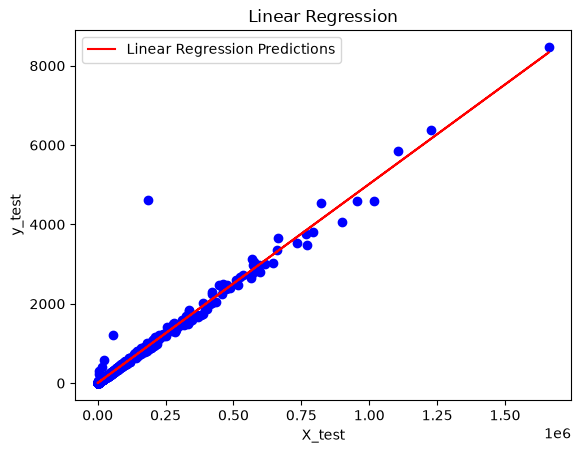

In [119]:
plt.scatter(X_test,y_test, color='blue')
plt.plot(X_test, model1.predict(X_test), color='red', label='Linear Regression Predictions')
plt.xlabel('X_test')
plt.ylabel('y_test')
plt.title('Linear Regression')
plt.legend()
plt.show()


### Step 22: Sample Inference on New Invoice Dollar Amounts
- **Input Data**: Invoices with `Dollars = [18500, 9000, 3000]`
- **Description**: Runs inference using the trained Linear Regression model to forecast freight costs for new incoming invoice amounts.


In [123]:
input_data = pd.DataFrame({'Dollars': [18500, 9000, 3000]})
predictions = model1.predict(input_data)
print(f"Predictions for input data:\n{predictions}")

Predictions for input data:
[97.78868161 50.14455838 20.05353318]
